# Resource-Management & Communications Performance (F1 / F2 / F3)

OpenMATB transparency study — objective performance on the two **non-automated**
tasks (resource management and communications), compared across the three
explanation forms. This is the primary objective measure for **H4** (saved
attention is redeployed: performance on non-automated tasks is higher under
F2/F3 than under F1).

> **Status:** pipeline prepared on pilot data; re-run unchanged once P01–P10 are collected.

## How performance is measured (literature)

**Resource management.** Two depleting tanks (A, B) must be held near a target of
2500 units. Performance is the **root-mean-square deviation (RMSD)** of tank level
from target, and the **proportion of time within tolerance** (±500 → 2000–3000).
- Cegarra, J., Valéry, B., Avril, E., Calmettes, C., & Navarro, J. (2020).
  *OpenMATB: A Multi-Attribute Task Battery…* Behavior Research Methods, 52, 1980–1990.
- Santiago-Espada, Y., Myer, R. R., Latorella, K. A., & Comstock, J. R. (2011).
  *The Multi-Attribute Task Battery II (MATB-II) Software… User's Guide.* NASA/TM-2011-217164.
- Comstock, J. R., & Arnegard, R. J. (1992). *The Multi-Attribute Task Battery…* NASA TM-104174.

**Communications.** Respond to own-call-sign radio requests (set the named radio to
the requested frequency), ignore distractor call signs. Scored as **response
accuracy** and **response time** within a signal-detection framing
(hit / miss / false alarm; OpenMATB also distinguishes wrong-radio / wrong-frequency
errors). Response time is the latency from end-of-call to a validated response, in
milliseconds, reported on hits only.
- Cegarra et al. (2020), as above.


In [1]:
import sys
from pathlib import Path

# Make the matb_analysis package importable when running from notebooks/.
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)


## 1. Load sessions and build the tidy metrics table

In [2]:
sessions = find_study_sessions()
print(f"Discovered {len(sessions)} study session(s):")
for s in sessions:
    print(f"  {s.path.name:32s} participant={s.participant:5s} kind={s.scenario_kind}")

table = build_metrics_table(sessions)
table.to_csv(OUT / "metrics_by_block.csv", index=False)
table


Discovered 12 study session(s):
  10_260509_181229.csv             participant=P01   kind=full
  7_260509_173635.csv              participant=P01   kind=full
  8_260509_173856.csv              participant=P01   kind=full
  9_260509_175616.csv              participant=P01   kind=full
  11_260514_102111.csv             participant=F2_A  kind=single_block
  12_260515_062446.csv             participant=F3_C  kind=single_block
  14_260516_113224.csv             participant=F1_A  kind=single_block
  15_260516_114636.csv             participant=F1_A  kind=single_block
  18_260530_084937.csv             participant=P01   kind=full
  19_260530_085432.csv             participant=P01   kind=full
  23_260530_114625.csv             participant=P01   kind=full
  24_260530_151227.csv             participant=P02   kind=full


,participant,form,block,session_file,rmsd_a,rmsd_b,rmsd_mean,mad_a,mad_b,pct_in_tolerance_a,...,n_miss,n_fa,n_bad_radio,n_bad_freq,n_bad_radio_freq,accuracy,miss_rate,fa_count,mean_rt_hit,mean_abs_freq_dev
0,P01,F1,A,10_260509_181229.csv,291.661162,310.580887,301.121025,234.903553,259.157360,62.436548,...,9,0,0,0,0,0.0,1.0,0,NaN,NaN
1,F2_A,F2,A,11_260514_102111.csv,233.707224,275.289762,254.498493,206.493333,252.893333,64.000000,...,6,0,0,0,0,0.0,1.0,0,NaN,NaN
2,F3_C,F3,C,12_260515_062446.csv,348.597189,256.003906,302.300547,329.000000,220.384615,19.230769,...,1,0,0,0,0,0.0,1.0,0,NaN,NaN
3,F1_A,F1,A,14_260516_113224.csv,469.082082,469.082082,469.082082,403.000000,403.000000,31.250000,...,1,0,0,0,0,0.0,1.0,0,NaN,NaN
4,F1_A,F1,A,15_260516_114636.csv,694.253556,694.253556,694.253556,598.000000,598.000000,21.276596,...,1,0,0,0,0,0.0,1.0,0,NaN,NaN
5,P01,F1,A,19_260530_085432.csv,897.680197,396.143481,646.911839,840.710526,360.776316,0.000000,...,7,0,0,0,0,0.0,1.0,0,NaN,NaN
6,P01,F2,B,19_260530_085432.csv,2396.213227,293.752819,1344.983023,2387.045752,211.189542,0.000000,...,6,0,0,0,0,0.0,1.0,0,NaN,NaN
7,P01,F3,C,19_260530_085432.csv,2480.015447,197.400608,1338.708027,2480.000000,167.961538,0.000000,...,6,0,0,0,0,0.0,1.0,0,NaN,NaN
8,P01,F1,A,23_260530_114625.csv,1417.852448,2014.649511,1716.250980,1415.739130,2000.195652,0.000000,...,4,0,0,0,0,0.0,1.0,0,NaN,NaN
9,P02,F1,A,24_260530_151227.csv,189.276870,185.124535,187.200702,151.080000,162.773333,80.000000,...,7,0,0,0,0,0.0,1.0,0,NaN,NaN


## 2. Resource management by form

RMSD from the 2500 target (lower = better) and percent time in tolerance
(higher = better).

In [3]:
resman_cols = ["rmsd_mean", "pct_in_tolerance_mean", "mad_a", "mad_b",
               "mean_excursion_sec", "n_excursions"]
resman_desc = (table.groupby("form")[resman_cols]
                    .agg(["mean", "median", "std"])
                    .reindex(FORM_ORDER))
resman_desc


rmsd_mean                         pct_in_tolerance_mean             \
            mean      median         std                  mean     median   
form                                                                        
F1    669.136697  557.996961  548.688037             34.034337  26.263298   
F2    584.836943  254.498493  660.181852             60.009768  55.666667   
F3    591.633404  302.300547  652.442151             55.915690  38.461538   

                      mad_a                                mad_b              \
            std        mean      median          std        mean      median   
form                                                                           
F1    29.579719  607.238868  500.500000   468.336431  630.650444  381.888158   
F2    26.825397  907.457841  206.493333  1281.948913  193.846610  211.189542   
F3    32.761392  979.105960  329.000000  1303.679607  159.519358  167.961538   

                 mean_excursion_sec                    n_excursions         \
             std               mean median         std         mean median   
form                                                                         
F1    686.774053          72.166667   76.5   38.184857     1.333333    0.5   
F2     69.363796         107.500000   66.5  100.482586     2.333333    2.0   
F3     65.495690          40.666667   40.0    9.018500     1.666667    2.0   

                
           std  
form            
F1    1.751190  
F2    1.527525  
F3    0.577350

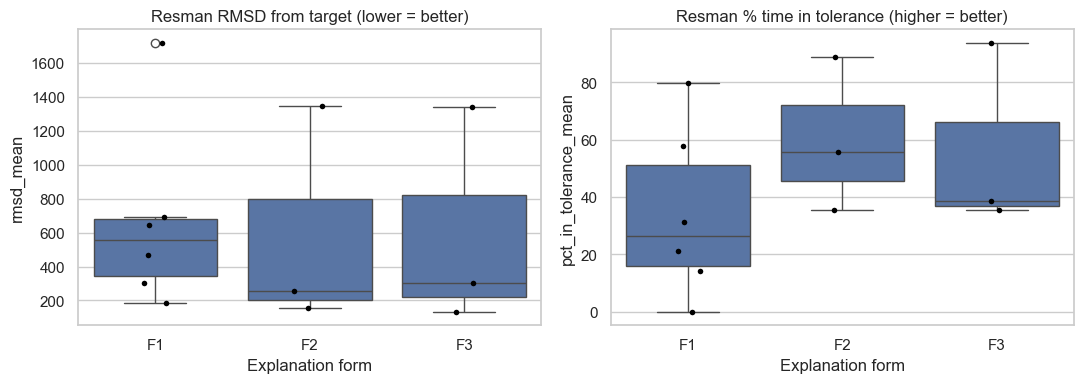

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["rmsd_mean", "pct_in_tolerance_mean"],
    ["Resman RMSD from target (lower = better)",
     "Resman % time in tolerance (higher = better)"],
):
    sns.boxplot(data=table, x="form", y=col, order=FORM_ORDER, ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER,
                  color="black", size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Explanation form")
fig.tight_layout()
fig.savefig(OUT / "resman_by_form.png", dpi=150)
plt.show()


## 3. Communications by form

Accuracy (hits / signal trials), response time on hits (ms), false-alarm count,
and frequency-setting error.

In [5]:
comms_cols = ["accuracy", "miss_rate", "fa_count", "mean_rt_hit",
              "mean_abs_freq_dev", "n_signal"]
comms_desc = (table.groupby("form")[comms_cols]
                   .agg(["mean", "median", "std"])
                   .reindex(FORM_ORDER))
comms_desc


accuracy             miss_rate             fa_count              \
         mean median  std      mean median  std     mean median  std   
form                                                                   
F1        0.0    0.0  0.0       1.0    1.0  0.0      0.0    0.0  0.0   
F2        0.0    0.0  0.0       1.0    1.0  0.0      0.0    0.0  0.0   
F3        0.0    0.0  0.0       1.0    1.0  0.0      0.0    0.0  0.0   

     mean_rt_hit            mean_abs_freq_dev             n_signal         \
            mean median std              mean median std      mean median   
form                                                                        
F1           NaN    NaN NaN               NaN    NaN NaN  4.833333    5.5   
F2           NaN    NaN NaN               NaN    NaN NaN  6.000000    6.0   
F3           NaN    NaN NaN               NaN    NaN NaN  4.333333    6.0   

                
           std  
form            
F1    3.371449  
F2    0.000000  
F3    2.886751

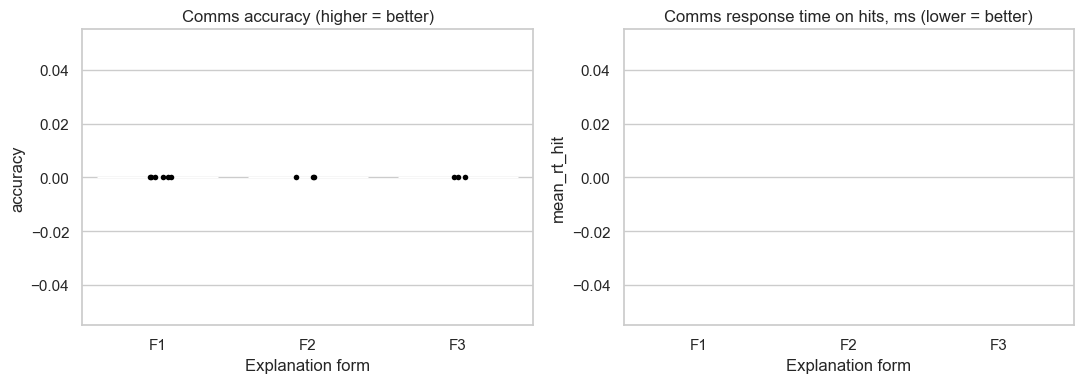

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["accuracy", "mean_rt_hit"],
    ["Comms accuracy (higher = better)",
     "Comms response time on hits, ms (lower = better)"],
):
    sns.barplot(data=table, x="form", y=col, order=FORM_ORDER,
                errorbar="sd", ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER,
                  color="black", size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Explanation form")
fig.tight_layout()
fig.savefig(OUT / "comms_by_form.png", dpi=150)
plt.show()


## 4. Summary table (H4)

One row per form with the headline non-automated-task measures. H4 predicts
F2/F3 ≥ F1 on accuracy and % in tolerance, and ≤ on RMSD and response time.

In [7]:
summary = (table.groupby("form")[
              ["rmsd_mean", "pct_in_tolerance_mean", "accuracy",
               "mean_rt_hit", "fa_count"]]
              .mean()
              .reindex(FORM_ORDER)
              .round(2))
summary.to_csv(OUT / "h4_summary_by_form.csv")
summary


,rmsd_mean,pct_in_tolerance_mean,accuracy,mean_rt_hit,fa_count
form,,,,,
F1,669.14,34.03,0.0,NaN,0.0
F2,584.84,60.01,0.0,NaN,0.0
F3,591.63,55.92,0.0,NaN,0.0


## 5. Inferential tests — to add when N is adequate

Deliberately omitted now (small pilot N). When P01–P10 are collected, add
within-subject tests across the three forms per metric (e.g. Friedman omnibus +
Wilcoxon signed-rank post-hoc, non-parametric), with assumptions stated. The tidy
table above (`outputs/metrics_by_block.csv`) is the input for those tests.
